In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, lfilter, sosfilt, welch, find_peaks
from scipy import stats
import pandas as pd
import calendar
import dask
dask.config.set(**{'array.slicing.split_large_chunks': True})
from pathlib import Path
import os

# Loading SST

In [2]:
# --- helpers ---------------------------------------------------
def norm_time(ds):
    if 'valid_time' in ds.coords and 'time' not in ds.coords:
        ds = ds.rename({'valid_time': 'time'})
    return ds

def wrap_lon(ds):
    """
    Wrap longitude to 0–360 regardless of whether the coord is named
    'lon' or 'longitude'.
    """
    if "longitude" in ds.coords:
        lon_name = "longitude"
    elif "lon" in ds.coords:
        lon_name = "lon"
    else:
        raise KeyError(f"No longitude coordinate found. Coords: {list(ds.coords)}")

    if float(ds[lon_name].max()) <= 180:
        ds = ds.assign_coords({lon_name: ds[lon_name] % 360}).sortby(lon_name)

    return ds

In [3]:
################## Load SST data from ERA5 for years 1980 to 2020 ##################
print("loading era5 sst...")
era5_sst_dir = Path("/glade/campaign/collections/rda/data/d633001/e5.moda.an.sfc")
era5_sst_files = sorted(str(p) for y in range(1979,2023)
                   for p in (era5_sst_dir / f"{y}").glob("*128_034_sstk*.nc"))
era5_sst_ds = wrap_lon(norm_time(xr.open_mfdataset(era5_sst_files, combine="by_coords"))).sel(time=slice('1979-01-01T00:00:00.000000000', '2022-12-31T00:00:00.000000000'))
era5_sst_var = "sstk" if "sstk" in era5_sst_ds else "SSTK"

################## Slice Nino3.4 box ##################
print("calculating nino3.4 for ERA5")
nino34_box_obs = era5_sst_ds[era5_sst_var].sel(
    latitude=slice(5, -5),    # 5°S to 5°N
    longitude=slice(190, 240) #170°W (190°E) to 120°W (240°E) #150W-90W for Nino3 #160E-150W for Nino4
    ) #.mean(dim=['latitude', 'longitude'])

# Calculate the area-weighted mean SST in the Niño 3.4 region
weights = np.cos(np.deg2rad(nino34_box_obs.latitude))
sst_nino34_mean = nino34_box_obs.weighted(weights).mean(dim=['latitude', 'longitude'])

climatology = sst_nino34_mean.groupby('time.month').mean(dim='time')

# Calculate anomalies Nino3.4 Index
nino34_obs_anom = sst_nino34_mean.groupby('time.month') - climatology #nino3.4 index

################## Global SST Anomalies ##################
climatology_global_obs = era5_sst_ds[era5_sst_var].groupby("time.month").mean(dim="time")

sst_anom = era5_sst_ds[era5_sst_var].groupby("time.month") - climatology_global_obs
print("done.")

loading era5 sst...
calculating nino3.4 for ERA5
done.


/glade/u/home/kkoepnick/my_conda_envs/my-npl/lib/python3.11/site-packages/xarray/core/indexing.py:1620: PerformanceWarning: Slicing with an out-of-order index is generating 44 times more chunks
  return self.array[key]
/glade/u/home/kkoepnick/my_conda_envs/my-npl/lib/python3.11/site-packages/xarray/core/indexing.py:1620: PerformanceWarning: Slicing with an out-of-order index is generating 44 times more chunks
  return self.array[key]


In [4]:
################## Load SST data from JRA-55 (single file) ##################
print("loading jra55 sst...")

jra55_sst_file = Path("/glade/campaign/univ/uhar0025/kkoepnick/jra55-sst/sst.mon.mean.nc")  

jra55_sst_ds = wrap_lon(
    norm_time(
        xr.open_dataset(jra55_sst_file)
    )
).sel(time=slice("1979-01-01", "2022-12-31"))

# robust SST var pick
jra55_sst_candidates = ["sst"]
jra55_sst_var = next((v for v in jra55_sst_candidates if v in jra55_sst_ds.data_vars), None)

if jra55_sst_var is None:
    raise KeyError(
        "Could not find an SST variable in JRA-55 dataset. "
        f"Available vars: {list(jra55_sst_ds.data_vars)}"
    )

print("JRA-55 SST var:", jra55_sst_var)

################## Slice Nino3.4 box (JRA-55) ##################
print("calculating nino3.4 for JRA-55")

jra55_sst = jra55_sst_ds[jra55_sst_var]
lat_name = "lat"
lon_name = "lon"

nino34_box_jra55 = jra55_sst.sel(
    **{
        lat_name: slice(5, -5),         # 5°N to 5°S (descending)
        lon_name: slice(190, 240)       # 170°W–120°W in 0–360
    }
)

# Area-weighted mean over Niño3.4
weights_jra55 = np.cos(np.deg2rad(nino34_box_jra55[lat_name]))
sst_nino34_mean_jra55 = nino34_box_jra55.weighted(weights_jra55).mean(dim=[lat_name, lon_name])

climatology_jra55 = sst_nino34_mean_jra55.groupby("time.month").mean(dim="time")
nino34_jra55_anom = sst_nino34_mean_jra55.groupby("time.month") - climatology_jra55

################## Global SST Anomalies (JRA-55) ##################
climatology_global_jra55 = jra55_sst.groupby("time.month").mean(dim="time")
sst_anom_global_jra55 = jra55_sst.groupby("time.month") - climatology_global_jra55
print("done.")

loading jra55 sst...
JRA-55 SST var: sst
calculating nino3.4 for JRA-55
done.


In [5]:
################## Load SST data from MERRA-2 (monthly nc4 in year subdirs) ##################
print("loading merra2 sst...")

merra2_sst_dir = Path("/glade/campaign/univ/uhar0025/kkoepnick/merra2-sst/") 
merra2_years = range(1980, 2023)  # 1980–2022 inclusive

# If your filenames include SST in the name, you can tighten to "*SST*.nc4"
merra2_sst_files = sorted(
    str(p)
    for y in merra2_years
    for p in (merra2_sst_dir / f"{y}").glob("*.nc4")
)

if len(merra2_sst_files) == 0:
    raise FileNotFoundError(f"No MERRA-2 SST .nc4 files found under: {merra2_sst_dir}")

merra2_sst_ds = wrap_lon(
    norm_time(
        xr.open_mfdataset(merra2_sst_files, combine="by_coords")
    )
).sel(time=slice("1980-01-01", "2022-12-31"))

# robust SST var pick
merra2_sst_candidates = ["TSKINWTR"]
merra2_sst_var = next((v for v in merra2_sst_candidates if v in merra2_sst_ds.data_vars), None)

if merra2_sst_var is None:
    raise KeyError(
        "Could not find an SST variable in MERRA-2 dataset. "
        f"Available vars: {list(merra2_sst_ds.data_vars)}"
    )

print("MERRA-2 SST var:", merra2_sst_var)

################## Slice Nino3.4 box (MERRA-2) ##################
print("calculating nino3.4 for MERRA-2")

merra2_sst = merra2_sst_ds[merra2_sst_var]
lat_name = "lat"
lon_name = "lon"

# physically reasonable SST range for Niño3.4
merra2_sst = merra2_sst.where(
    (merra2_sst > 295.0) & (merra2_sst < 305.0)
)

nino34_box_merra2 = merra2_sst.sel(
    **{
        lat_name: slice(-5, 5),
        lon_name: slice(190, 240)
    }
)

weights_merra2 = np.cos(np.deg2rad(nino34_box_merra2[lat_name]))
sst_nino34_mean_merra2 = nino34_box_merra2.weighted(weights_merra2).mean(dim=[lat_name, lon_name])

climatology_merra2 = sst_nino34_mean_merra2.groupby("time.month").mean(dim="time")
nino34_merra2_anom = sst_nino34_mean_merra2.groupby("time.month") - climatology_merra2

################## Global SST Anomalies (MERRA-2) ##################
climatology_global_merra2 = merra2_sst.groupby("time.month").mean(dim="time")
sst_anom_global_merra2 = merra2_sst.groupby("time.month") - climatology_global_merra2
print("done.")

loading merra2 sst...
MERRA-2 SST var: TSKINWTR
calculating nino3.4 for MERRA-2
done.


/glade/u/home/kkoepnick/my_conda_envs/my-npl/lib/python3.11/site-packages/xarray/core/indexing.py:1620: PerformanceWarning: Slicing with an out-of-order index is generating 43 times more chunks
  return self.array[key]
/glade/u/home/kkoepnick/my_conda_envs/my-npl/lib/python3.11/site-packages/xarray/core/indexing.py:1620: PerformanceWarning: Slicing with an out-of-order index is generating 43 times more chunks
  return self.array[key]


In [6]:
def _as_time(da):
    if "valid_time" in da.dims:
        da = da.rename(valid_time="time")
    return da.sortby("time")

def plot_nino_panel(ax, da, title, panel_label, thr=None):
    # convert once (fast + avoids xarray/ufunc surprises)
    t = da["time"].values
    y = np.asarray(da.values)

    if thr is None:
        thr = float(da.std(dim="time").values)  # python float

    ax.plot(t, y, color="black", linewidth=1)

    en = y > thr
    ln = y < -thr

    ax.fill_between(t, y, thr, where=en, alpha=0.3, interpolate=True,
                    color="r", label="El Niño")
    ax.fill_between(t, y, -thr, where=ln, alpha=0.3, interpolate=True,
                    color="b", label="La Niña")

    ax.axhline(thr, c="r", linestyle="--", linewidth=0.8)
    ax.axhline(-thr, c="b", linestyle="--", linewidth=0.8)

    ax.set_title(title)
    ax.text(0.01, 0.92, panel_label, transform=ax.transAxes, fontweight="bold")


# --- prep data ---
datasets = [
    ("ERA5 Niño3.4 Index", _as_time(nino34_obs_anom), "(a)"),
    ("JRA-55 Niño3.4 Index", _as_time(nino34_jra55_anom), "(b)"),
    ("MERRA-2 Niño3.4 Index", _as_time(nino34_merra2_anom), "(c)"),
]

# # y-lims (convert mins/maxes to floats)
# ymin = float(min(float(da.min().values) for _, da, _ in datasets))
# ymax = float(max(float(da.max().values) for _, da, _ in datasets))
# pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
# ylims = (ymin - pad, ymax + pad)

# fig, axes = plt.subplots(
#     nrows=len(datasets), ncols=1, sharex=True,
#     figsize=(10, 6), constrained_layout=True, dpi=200
# )

# for i, (ax, (title, da, lab)) in enumerate(zip(axes, datasets)):
#     thr = float(da.std(dim="time").values)  # scalar float
#     plot_nino_panel(ax, da, title, lab, thr=thr)

#     ax.set_ylim(*ylims)
#     ax.set_ylabel(r"Niño3.4 Index ($^\circ$C)")
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     # only one legend (faster + cleaner)
#     if i == 0:
#         ax.legend(loc="upper right")

# axes[-1].set_xlabel("Time")
# plt.savefig(
#     "figures/ninoindex_alldata.pdf",
#     dpi=200,
#     bbox_inches="tight",
#     format="pdf"
# )
# plt.show()

In [7]:
era5_nino34 = _as_time(nino34_obs_anom).drop_vars("month", errors="ignore").rename("ERA5")
jra55_nino34 = _as_time(nino34_jra55_anom).drop_vars("month", errors="ignore").rename("JRA55")
merra2_nino34 = _as_time(nino34_merra2_anom).drop_vars("month", errors="ignore").rename("MERRA2")

ds_nino34_obs = xr.merge(
    [era5_nino34, jra55_nino34, merra2_nino34],
    join="outer",
    compat="override",
)

ds_nino34_obs.attrs["description"] = "Monthly Niño3.4 SST anomaly indices for ERA5, JRA-55, and MERRA-2"
ds_nino34_obs.attrs["region"] = "5S-5N, 170W-120W"
ds_nino34_obs.attrs["climatology"] = "monthly climatology removed over each dataset time period"

outfile = "/glade/derecho/scratch/kkoepnick/nino34_obs_1979_2022.nc"
ds_nino34_obs.to_netcdf(outfile)
print(outfile)

/glade/derecho/scratch/kkoepnick/tmp/ipykernel_183661/1171840838.py:16: UserWarning: Times can't be serialized faithfully to int64 with requested units 'hours since 1900-01-01'. Serializing with units 'minutes since 1900-01-01' instead. Set encoding['dtype'] to floating point dtype to serialize with units 'hours since 1900-01-01'. Set encoding['units'] to 'minutes since 1900-01-01' to silence this warning .
  ds_nino34_obs.to_netcdf(outfile)


/glade/derecho/scratch/kkoepnick/nino34_obs_1979_2022.nc


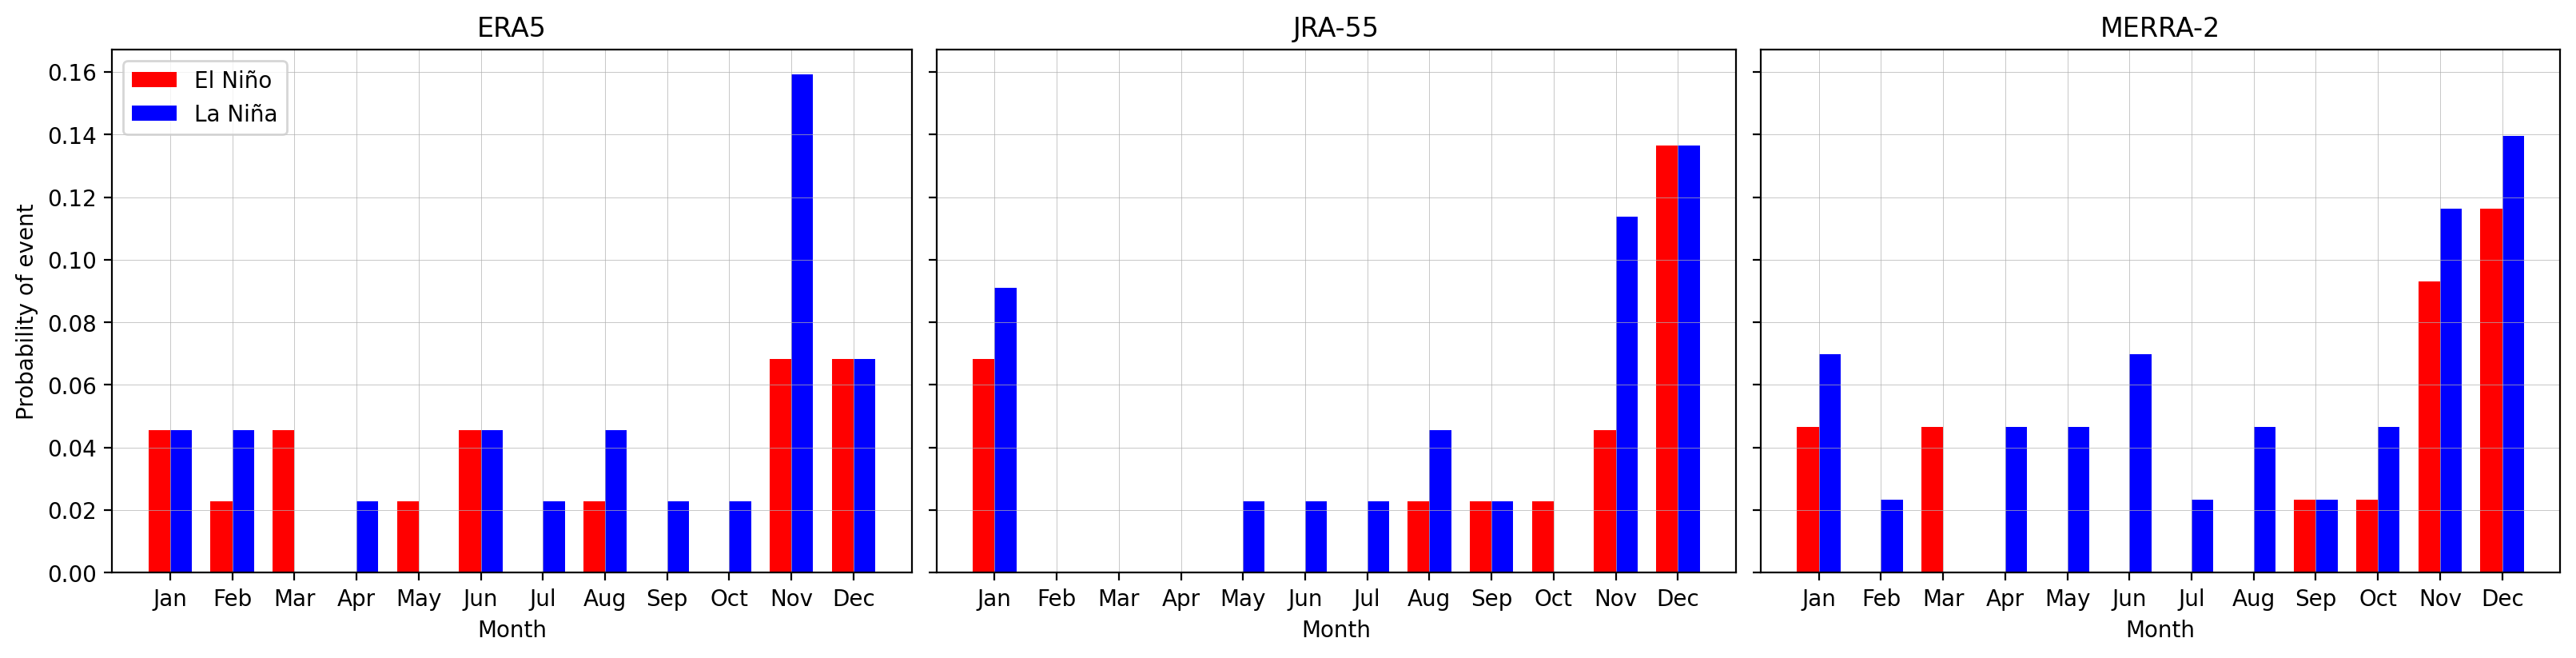

In [8]:
def remove_monthly_climatology(y):
    y = np.asarray(y, float)
    clim = np.full(12, np.nan)
    for m in range(12):
        clim[m] = np.nanmean(y[m::12])
    y_anom = y - clim[np.arange(len(y)) % 12]
    return y_anom, clim

def local_maxima_peaks(y, threshold):
    y = np.asarray(y, float)
    ok = np.isfinite(y)
    peaks = []
    for i in range(1, len(y) - 1):
        if not (ok[i-1] and ok[i] and ok[i+1]):
            continue
        if (y[i] > y[i-1]) and (y[i] > y[i+1]) and (y[i] >= threshold):
            peaks.append(i)
    return np.array(peaks, dtype=int)
    
def monthly_enso_peak_probability_obs(da, thr=None):
    da = _as_time(da)

    y = da.values.astype(float)
    y_anom, _ = remove_monthly_climatology(y)

    if thr is None:
        thr = np.nanstd(y_anom)

    el_idx = local_maxima_peaks(y_anom, thr)
    la_idx = local_maxima_peaks(-y_anom, thr)

    months = da["time.month"].values

    el_counts = np.zeros(12, dtype=int)
    la_counts = np.zeros(12, dtype=int)

    for i in el_idx:
        el_counts[months[i] - 1] += 1

    for i in la_idx:
        la_counts[months[i] - 1] += 1

    n_years = len(np.unique(da["time.year"].values))

    return el_counts / n_years, la_counts / n_years, thr


datasets = [
    ("ERA5", _as_time(nino34_obs_anom), "(a)"),
    ("JRA-55", _as_time(nino34_jra55_anom), "(b)"),
    ("MERRA-2", _as_time(nino34_merra2_anom), "(c)"),
]

months = np.arange(1, 13)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

width = 0.35

fig, axs = plt.subplots(
    1, 3,
    figsize=(16, 4),
    dpi=200,
    sharey=True,
    constrained_layout=True
)

for ax, (name, da, panel_label) in zip(axs, datasets):
    el_prob, la_prob, thr = monthly_enso_peak_probability_obs(da)
    ax.grid(lw=0.25)
    ax.bar(months - width/2, el_prob, width, color='r', label="El Niño")
    ax.bar(months + width/2, la_prob, width, color='b', label="La Niña")

    ax.set_title(name)

    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")

axs[0].set_ylabel("Probability of event")
axs[0].legend(frameon=True)

plt.savefig(
    "figures/monthly_enso_probability_alldata.pdf",
    dpi=200,
    bbox_inches="tight",
    format="pdf"
)

plt.show()

In [13]:
enso_probs = {}

for name, da, panel_label in datasets:
    el_prob, la_prob, thr = monthly_enso_peak_probability_obs(da)

    enso_probs[name] = {
        "el_nino": el_prob,
        "la_nina": la_prob,
        "threshold": thr,
    }

In [14]:
import pickle

In [16]:
enso_probs_save = {}

for name in enso_probs:
    enso_probs_save[name] = {
        "el_nino": np.asarray(enso_probs[name]["el_nino"]),
        "la_nina": np.asarray(enso_probs[name]["la_nina"]),
        "threshold": float(enso_probs[name]["threshold"]),
        "month": np.arange(1, 13),
    }

with open("enso_monthly_probabilities.pkl", "wb") as f:
    pickle.dump(enso_probs_save, f)

# Loading Wind from observations.ipynb

In [7]:
wind_anom_era5 = xr.open_dataset("/glade/campaign/univ/uhar0025/kkoepnick/qbo_u50_bandpassed_ERA5.nc").__xarray_dataarray_variable__

In [8]:
wind_anom_jra55 = xr.open_dataset("/glade/campaign/univ/uhar0025/kkoepnick/qbo_u50_bandpassed_JRA55.nc").__xarray_dataarray_variable__

In [9]:
wind_anom_merra2 = xr.open_dataset("/glade/campaign/univ/uhar0025/kkoepnick/qbo_u50_bandpassed_MERRA2.nc").__xarray_dataarray_variable__

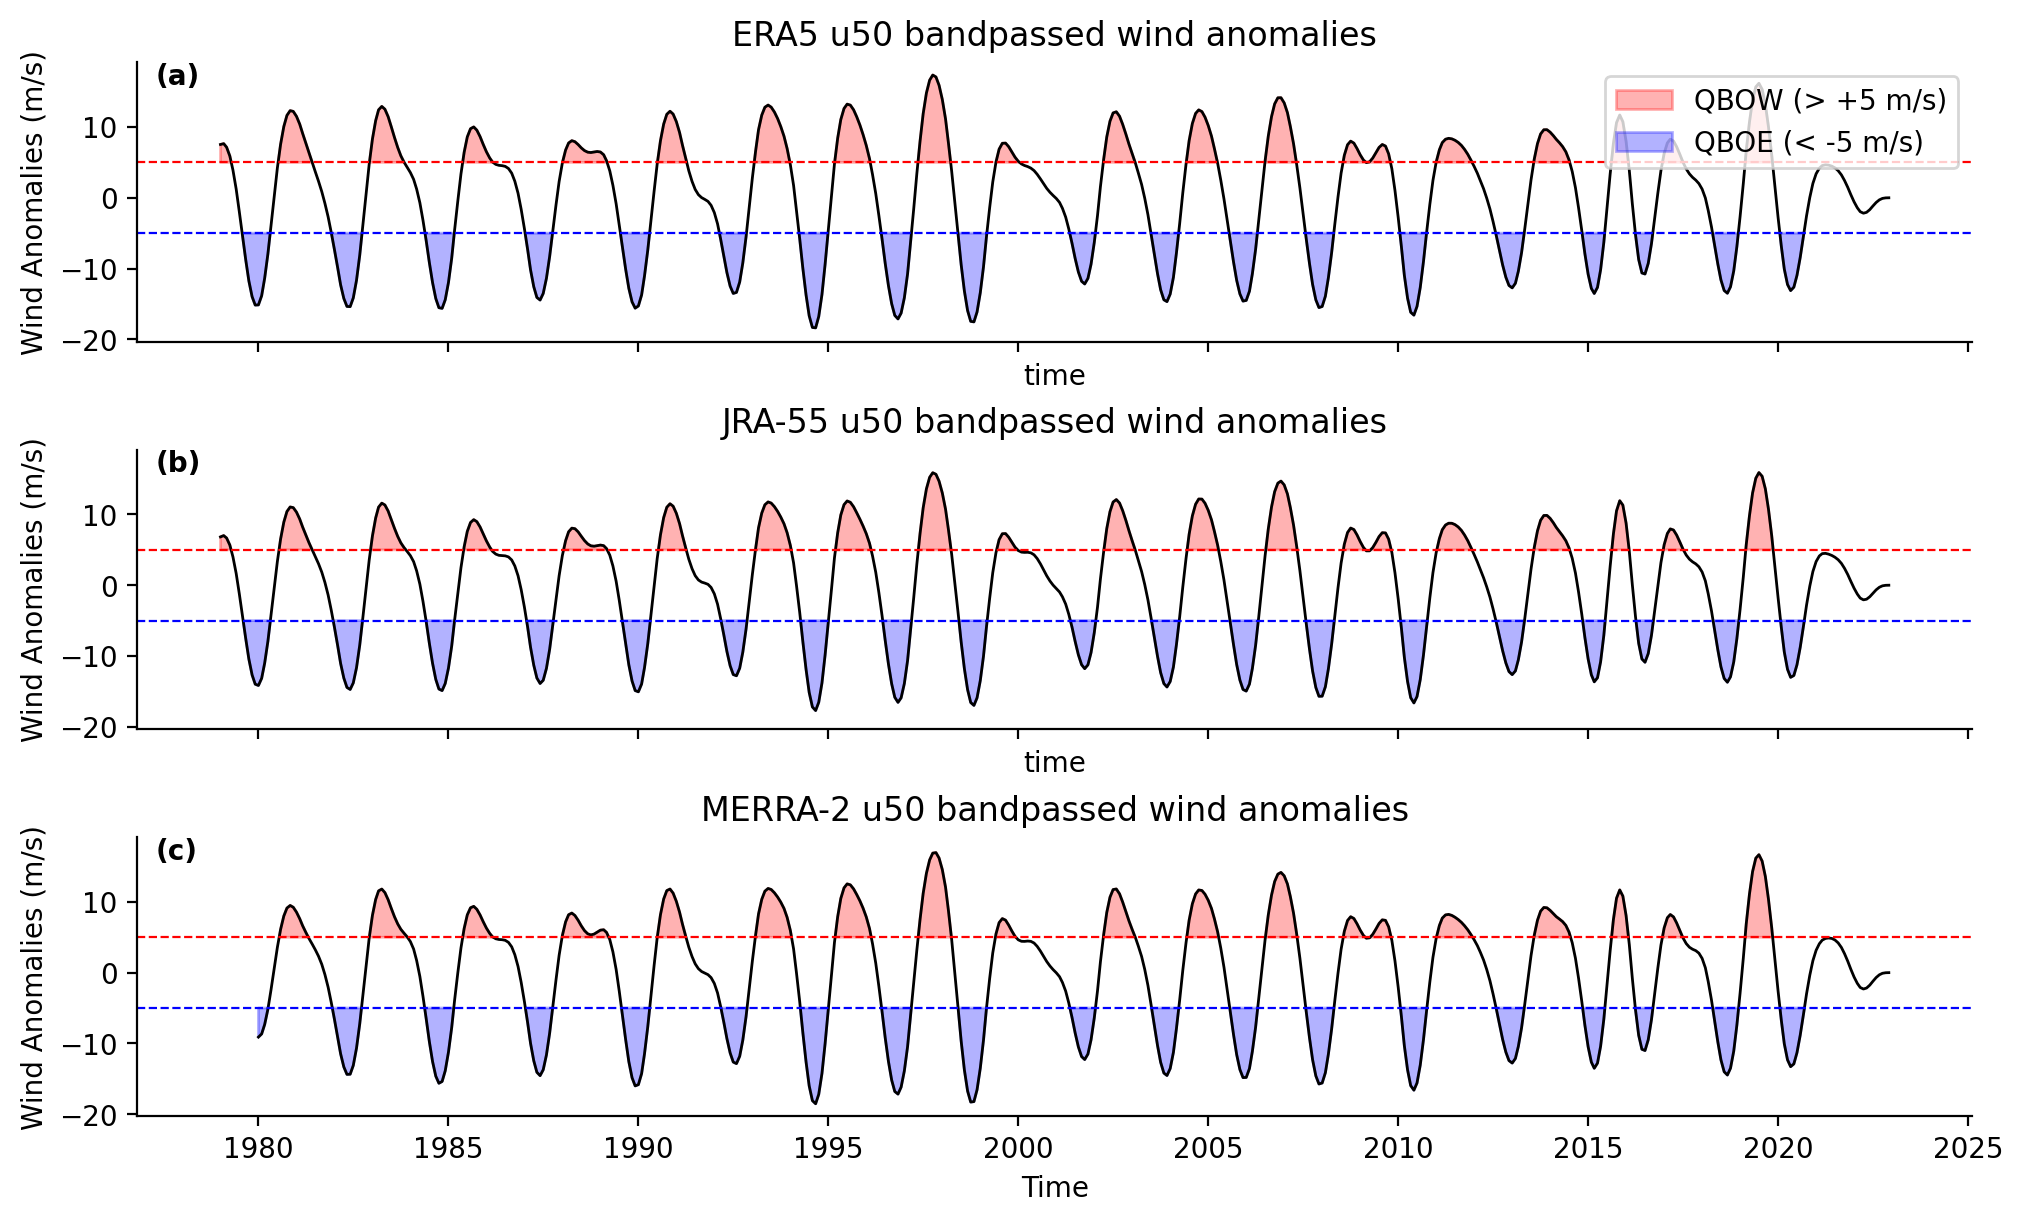

In [12]:
thr = 5.0  # m/s threshold

def _as_time(da):
    if "valid_time" in da.dims:
        da = da.rename(valid_time="time")
    return da.sortby("time")

def plot_u50_panel(ax, da, title, panel_label, thr=5.0):
    da.plot(ax=ax, color="black", linewidth=1)

    t = da["time"].values
    y = da.values

    ax.fill_between(
        t, y, thr, where=(y > thr),
        alpha=0.3, interpolate=True, color="r", label="QBOW (> +5 m/s)"
    )
    ax.fill_between(
        t, y, -thr, where=(y < -thr),
        alpha=0.3, interpolate=True, color="b", label="QBOE (< -5 m/s)"
    )

    ax.axhline(thr, c="r", linestyle="--", linewidth=0.8)
    ax.axhline(-thr, c="b", linestyle="--", linewidth=0.8)

    ax.set_title(title)
    ax.text(0.01, 0.92, panel_label, transform=ax.transAxes, fontweight="bold")

# --- prep data ---
datasets = [
    ("ERA5 u50 bandpassed wind anomalies", _as_time(wind_anom_era5),   "(a)"),
    ("JRA-55 u50 bandpassed wind anomalies", _as_time(wind_anom_jra55), "(b)"),
    ("MERRA-2 u50 bandpassed wind anomalies", _as_time(wind_anom_merra2), "(c)"),
]

# consistent y-limits
ymin = float(min(da.min() for _, da, _ in datasets))
ymax = float(max(da.max() for _, da, _ in datasets))
pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
ylims = (ymin - pad, ymax + pad)

# --- plot ---
fig, axes = plt.subplots(
    nrows=len(datasets), ncols=1, sharex=True,
    figsize=(10, 6), constrained_layout=True, dpi=200
)

for ax, (title, da, lab) in zip(axes, datasets):

    thr = 5   

    plot_u50_panel(ax, da, title, lab, thr=thr)

    ax.set_ylim(*ylims)
    ax.set_ylabel("Wind Anomalies (m/s)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(loc="upper right")

axes[-1].set_xlabel("Time")
plt.savefig(
    "/glade/u/home/kkoepnick/qbo-enso/seasonality-cmip/revision-1/figures/u50_bandpassed_alldata.pdf",
    dpi=200,
    bbox_inches="tight",
    format="pdf"
)
plt.show()


# Analysis

In [50]:
enso_threshold_era5 = 1 * nino34_obs_anom.std(dim='time').compute()
print("era5 enso threshold:", enso_threshold_era5)
# Define ENSO events using the Nino3.4 time series (these are 1D arrays over time)
el_nino_mask_era5 = nino34_obs_anom > enso_threshold_era5
la_nina_mask_era5 = nino34_obs_anom < -enso_threshold_era5

# QBO: use pm 5.0 m/s thresholds on the wind anomalies
qbo_threshold_era5 = 5 #wind_anom_era5.std() #0.0
print("era5 qbo threshold:", qbo_threshold_era5)
qboe_mask_era5 = wind_anom_era5 < -qbo_threshold_era5   # QBO easterly events
qbow_mask_era5 = wind_anom_era5 > qbo_threshold_era5    # QBO westerly events

era5 enso threshold: <xarray.DataArray 'SSTK' ()> Size: 8B
array(0.90642706)
era5 qbo threshold: 5


In [51]:
enso_threshold_jra55 = 1 * nino34_jra55_anom.std(dim='time').compute()
print("era5 enso threshold:", enso_threshold_jra55)
# Define ENSO events using the Nino3.4 time series (these are 1D arrays over time)
el_nino_mask_jra55 = nino34_jra55_anom > enso_threshold_jra55
la_nina_mask_jra55 = nino34_jra55_anom < -enso_threshold_jra55

# QBO: use pm 5.0 m/s thresholds on the wind anomalies
qbo_threshold_jra55 = 5 #wind_anom_jra55.std()
print("jra55 qbo threshold:", qbo_threshold_jra55)
qboe_mask_jra55 = wind_anom_jra55 < -qbo_threshold_jra55   # QBO easterly events
qbow_mask_jra55 = wind_anom_jra55 > qbo_threshold_jra55    # QBO westerly events

era5 enso threshold: <xarray.DataArray 'sst' ()> Size: 8B
array(0.88772142)
jra55 qbo threshold: 5


In [52]:
enso_threshold_merra2 = 1 * nino34_merra2_anom.std(dim='time').compute()
print("era5 enso threshold:", enso_threshold_merra2)
# Define ENSO events using the Nino3.4 time series (these are 1D arrays over time)
el_nino_mask_merra2 = nino34_merra2_anom > enso_threshold_merra2
la_nina_mask_merra2 = nino34_merra2_anom < -enso_threshold_merra2

# QBO: use pm 5.0 m/s thresholds on the wind anomalies
qbo_threshold_merra2 = 5 #wind_anom_merra2.std()
print("merra2 qbo threshold:", qbo_threshold_merra2)
qboe_mask_merra2 = wind_anom_merra2 < -qbo_threshold_merra2   # QBO easterly events
qbow_mask_merra2 = wind_anom_merra2 > qbo_threshold_merra2    # QBO westerly events

era5 enso threshold: <xarray.DataArray 'TSKINWTR' ()> Size: 8B
array(0.84183983)
merra2 qbo threshold: 5


In [53]:
el_nino_times_era5 = nino34_obs_anom.where(el_nino_mask_era5).time
la_nina_times_era5 = nino34_obs_anom.where(la_nina_mask_era5).time
qboe_times_era5 = wind_anom_era5.where(qboe_mask_era5).time
qbow_times_era5 = wind_anom_era5.where(qbow_mask_era5).time

el_nino_times_jra55 = nino34_jra55_anom.where(el_nino_mask_jra55).time
la_nina_times_jra55 = nino34_jra55_anom.where(la_nina_mask_jra55).time
qboe_times_jra55 = wind_anom_jra55.where(qboe_mask_jra55).time
qbow_times_jra55 = wind_anom_jra55.where(qbow_mask_jra55).time

el_nino_times_merra2 = nino34_merra2_anom.where(el_nino_mask_merra2).time
la_nina_times_merra2 = nino34_merra2_anom.where(la_nina_mask_merra2).time
qboe_times_merra2 = wind_anom_merra2.where(qboe_mask_merra2).time
qbow_times_merra2 = wind_anom_merra2.where(qbow_mask_merra2).time

In [54]:
el_nino_era5 = nino34_obs_anom.where(el_nino_mask_era5)#.values
la_nina_era5 = nino34_obs_anom.where(la_nina_mask_era5)#.values
qboe_era5 = wind_anom_era5.where(qboe_mask_era5)#.values
qbow_era5 = wind_anom_era5.where(qbow_mask_era5)#.values

el_nino_jra55 = nino34_jra55_anom.where(el_nino_mask_jra55)#.values
la_nina_jra55 = nino34_jra55_anom.where(la_nina_mask_jra55)#.values
qboe_jra55 = wind_anom_jra55.where(qboe_mask_jra55)#.values
qbow_jra55 = wind_anom_jra55.where(qbow_mask_jra55)#.values

el_nino_merra2 = nino34_merra2_anom.where(el_nino_mask_merra2)#.values
la_nina_merra2 = nino34_merra2_anom.where(la_nina_mask_merra2)#.values
qboe_merra2 = wind_anom_merra2.where(qboe_mask_merra2)#.values
qbow_merra2 = wind_anom_merra2.where(qbow_mask_merra2)#.values

In [55]:
global_el_nino_era5 = sst_anom.where(el_nino_mask_era5)#.values
global_la_nina_era5 = sst_anom.where(la_nina_mask_era5)#.values
global_sst_during_qboe_era5 = sst_anom.where(qboe_mask_era5)#.values
global_sst_during_qbow_era5 = sst_anom.where(qbow_mask_era5)#.values

global_el_nino_jra55 = sst_anom_global_jra55.where(el_nino_mask_jra55)#.values
global_la_nina_jra55 = sst_anom_global_jra55.where(la_nina_mask_jra55)#.values
global_sst_during_qboe_jra55 = sst_anom_global_jra55.where(qboe_mask_jra55)#.values
global_sst_during_qbow_jra55 = sst_anom_global_jra55.where(qbow_mask_jra55)#.values

global_el_nino_merra2 = sst_anom_global_merra2.where(el_nino_mask_merra2)#.values
global_la_nina_merra2 = sst_anom_global_merra2.where(la_nina_mask_merra2)#.values
global_sst_during_qboe_merra2 = sst_anom_global_merra2.where(qboe_mask_merra2)#.values
global_sst_during_qbow_merra2 = sst_anom_global_merra2.where(qbow_mask_merra2)#.values

In [56]:
def composite_by_year(da):
    """
    Compute a 3-month composite using proper DJF (and cross‐year) averaging,
    but skip the first DJF (January composite of the first year) and the last NDJ
    (December composite of the last year), which are incomplete.

    For each month:
      - January: if not the first year, average previous December, current January, and current February.
      - December: if not the last year, average current November, current December, and next January.
      - All other months: average previous, current, and next month.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with a time dimension (named "valid_time") and monthly data.
        For example, shape could be (time=480, lat, lon) or just (time=480).

    Returns
    -------
    da_comp : xarray.DataArray
        Composite DataArray with dimensions ('year', 'month', …).
        Note that the first year will not have a January composite and
        the last year will not have a December composite.
    """

    # 1) Rename "valid_time" -> "time" to simplify
    if "valid_time" in da.dims:
        da = da.rename(valid_time="time")

    # 2) Create year and month coordinates from "time"
    da = da.assign_coords(
        year=da.time.dt.year, 
        month=da.time.dt.month
    )

    # 3) Sort the data by time just to be sure
    da = da.sortby("time")

    # 4) Gather the unique years in ascending order
    years = np.sort(np.unique(da.year.values))

    comp_list_years = []

    for yi, year in enumerate(years):

        # Subset to the current year's data
        current = da.where(da.year == year, drop=True)

        comp_list_month = []
        for m in range(1, 13):
            # Skip the first January composite (incomplete DJF) for the first year
            if yi == 0 and m == 1:
                continue
            # Skip the last December composite (incomplete NDJ) for the last year
            if yi == len(years) - 1 and m == 12:
                continue

            if m == 1:
                # January composite (complete composite, requires previous December)
                dec_prev = da.where((da.year == years[yi - 1]) & (da.month == 12), drop=True)
                jan = current.where(current.month == 1, drop=True)
                feb = current.where(current.month == 2, drop=True)
                slices = xr.concat([dec_prev, jan, feb], dim="time")

            elif m == 12:
                # December composite (complete composite, requires next January)
                nov = current.where(current.month == 11, drop=True)
                dec = current.where(current.month == 12, drop=True)
                jan_next = da.where((da.year == years[yi + 1]) & (da.month == 1), drop=True)
                slices = xr.concat([nov, dec, jan_next], dim="time")

            else:
                # All other months: previous, current, and next
                slices = current.where(current.month.isin([m-1, m, m+1]), drop=True)

            # 5) Average over "time" to collapse the 2 or 3 months -> single composite
            comp = slices.mean(dim="time", skipna=True)

            # 6) Expand so that we have a 'month' dimension
            comp = comp.expand_dims(month=[m])
            comp_list_month.append(comp)

        # 7) Concatenate the monthly composites along 'month'
        comp_year = xr.concat(comp_list_month, dim="month")
        comp_year = comp_year.assign_coords(year=year)
        comp_list_years.append(comp_year)

    # 8) Concatenate over all years
    da_comp = xr.concat(comp_list_years, dim="year")

    return da_comp

In [57]:
# For sea surface temperature anomalies:
sst_comp_test_era5 = composite_by_year(sst_anom)
# For wind anomalies:
wind_comp_test_era5 = composite_by_year(wind_anom_era5)
print(wind_comp_test_era5.values.shape)

# For sea surface temperature anomalies:
sst_comp_test_jra55 = composite_by_year(sst_anom_global_jra55)
sst_comp_test_jra55 = sst_comp_test_jra55.rename(
    {"lat": "latitude", "lon": "longitude"}
)
# For wind anomalies:
wind_comp_test_jra55 = composite_by_year(wind_anom_jra55)
print(wind_comp_test_jra55.values.shape)

# For sea surface temperature anomalies:
sst_comp_test_merra2 = composite_by_year(sst_anom_global_merra2)
sst_comp_test_merra2 = sst_comp_test_merra2.rename(
    {"lat": "latitude", "lon": "longitude"}
)
# For wind anomalies:
wind_comp_test_merra2 = composite_by_year(wind_anom_merra2)
print(wind_comp_test_merra2.values.shape)

(44, 12)
(44, 12)
(43, 12)


In [58]:
era5_numyrs = wind_comp_test_era5.values.shape[0]
print(era5_numyrs*12)

jra55_numyrs = wind_comp_test_jra55.values.shape[0]
print(jra55_numyrs*12)

merra2_numyrs = wind_comp_test_merra2.values.shape[0]
print(merra2_numyrs*12)

528
528
516


In [63]:
qboe_mask_new_era5 = wind_comp_test_era5.values.reshape(era5_numyrs*12) < -qbo_threshold_era5#.values
qbow_mask_new_era5 = wind_comp_test_era5.values.reshape(era5_numyrs*12) > qbo_threshold_era5#.values #42 x 12

qboe_mask_new_jra55 = wind_comp_test_jra55.values.reshape(jra55_numyrs*12) < -qbo_threshold_jra55#.values
qbow_mask_new_jra55 = wind_comp_test_jra55.values.reshape(jra55_numyrs*12) > qbo_threshold_jra55#.values #42 x 12

qboe_mask_new_merra2 = wind_comp_test_merra2.values.reshape(merra2_numyrs*12) < -qbo_threshold_merra2#.values
qbow_mask_new_merra2 = wind_comp_test_merra2.values.reshape(merra2_numyrs*12) > qbo_threshold_merra2#.values #42 x 12

In [64]:
# ERA5 dims: ('month','latitude','longitude','year')
da_era5 = sst_comp_test_era5.transpose("year", "month", "latitude", "longitude")

da_time_era5 = da_era5.stack(time=("year", "month"))

sst_anom_new_da_era5 = (
    da_time_era5
    .assign_coords(time=sst_anom["time"])
    .transpose("time", "latitude", "longitude")
    .chunk({"time": 120})
)

# JRA55 dims: ('month','lat','lon','year')
da_jra55 = sst_comp_test_jra55.transpose("year", "month", "latitude", "longitude")

da_time_jra55 = da_jra55.stack(time=("year", "month"))

sst_anom_new_da_jra55 = (
    da_time_jra55
    .assign_coords(time=sst_anom_global_jra55["time"])
    .transpose("time", "latitude", "longitude")
    .chunk({"time": 120})
)

# MERRA2 dims: ('month','latitude','longitude','year')
da_merra2 = sst_comp_test_merra2.transpose("year", "month", "latitude", "longitude")

da_time_merra2 = da_merra2.stack(time=("year", "month"))

sst_anom_new_da_merra2 = (
    da_time_merra2
    .assign_coords(time=sst_anom_global_merra2["time"])
    .transpose("time", "latitude", "longitude")
    .chunk({"time": 120})
)

/glade/derecho/scratch/kkoepnick/tmp/ipykernel_155642/1704353507.py:8: FutureWarning: updating coordinate 'time' with a PandasMultiIndex would leave the multi-index level coordinates ['year', 'month'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['time', 'year', 'month'])` before assigning new coordinate values.
  .assign_coords(time=sst_anom["time"])
/glade/derecho/scratch/kkoepnick/tmp/ipykernel_155642/1704353507.py:20: FutureWarning: updating coordinate 'time' with a PandasMultiIndex would leave the multi-index level coordinates ['year', 'month'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['time', 'year', 'month'])` before assigning new coordinate values.
  .assign_coords(time=sst_anom_global_jra55["time"])
/glade/derecho/scratch/kkoepnick/tmp/ipykernel_155642/1704353507.py:32: FutureWarning: updating coordinate 'time' with a PandasMultiIndex would leave the multi-index level coordinates ['year', 'month'] in

In [65]:
##### ERA5 #####

nino34_box_obs_new_era5 = sst_anom_new_da_era5.sel(
    latitude=slice(5, -5),    # 5°S to 5°N
    longitude=slice(190, 240) #170°W (190°E) to 120°W (240°E)
    ) #.mean(dim=['latitude', 'longitude'])

# Calculate the area-weighted mean SST in the Niño 3.4 region
weights_new_era5 = np.cos(np.deg2rad(nino34_box_obs_new_era5.latitude))
sst_nino34_mean_new_era5 = nino34_box_obs_new_era5.weighted(weights_new_era5).mean(dim=['latitude', 'longitude'])

climatology_new_era5 = sst_nino34_mean_new_era5.groupby('time.month').mean(dim='time')

# Calculate anomalies Nino3.4 Index
nino34_obs_anom_new_era5 = sst_nino34_mean_new_era5.groupby('time.month') - climatology_new_era5 #nino3.4 index
nino34_obs_anom_new_reshape_era5 = nino34_obs_anom_new_era5.values.reshape(era5_numyrs,12)

##### JRA55 #####

nino34_box_obs_new_jra55 = sst_anom_new_da_jra55.sel(
    latitude=slice(5, -5),    # 5°S to 5°N
    longitude=slice(190, 240) #170°W (190°E) to 120°W (240°E)
    ) #.mean(dim=['latitude', 'longitude'])

# Calculate the area-weighted mean SST in the Niño 3.4 region
weights_new_jra55 = np.cos(np.deg2rad(nino34_box_obs_new_jra55.latitude))
sst_nino34_mean_new_jra55 = nino34_box_obs_new_jra55.weighted(weights_new_jra55).mean(dim=['latitude', 'longitude'])

climatology_new_jra55 = sst_nino34_mean_new_jra55.groupby('time.month').mean(dim='time')

# Calculate anomalies Nino3.4 Index
nino34_obs_anom_new_jra55 = sst_nino34_mean_new_jra55.groupby('time.month') - climatology_new_jra55 #nino3.4 index
nino34_obs_anom_new_reshape_jra55 = nino34_obs_anom_new_jra55.values.reshape(jra55_numyrs,12)

##### MERRA2 #####

nino34_box_obs_new_merra2 = sst_anom_new_da_merra2.sel(
    latitude=slice(-5, 5),    # 5°S to 5°N
    longitude=slice(190, 240) #170°W (190°E) to 120°W (240°E)
    ) #.mean(dim=['latitude', 'longitude'])

# Calculate the area-weighted mean SST in the Niño 3.4 region
weights_new_merra2 = np.cos(np.deg2rad(nino34_box_obs_new_merra2.latitude))
sst_nino34_mean_new_merra2 = nino34_box_obs_new_merra2.weighted(weights_new_merra2).mean(dim=['latitude', 'longitude'])

climatology_new_merra2 = sst_nino34_mean_new_merra2.groupby('time.month').mean(dim='time')

# Calculate anomalies Nino3.4 Index
nino34_obs_anom_new_merra2 = sst_nino34_mean_new_merra2.groupby('time.month') - climatology_new_merra2 #nino3.4 index
nino34_obs_anom_new_reshape_merra2 = nino34_obs_anom_new_merra2.values.reshape(merra2_numyrs,12)

In [66]:
lanina_mask_new_era5 = nino34_obs_anom_new_era5 < -enso_threshold_era5
elnino_mask_new_era5 = nino34_obs_anom_new_era5 > enso_threshold_era5

lanina_mask_new_jra55 = nino34_obs_anom_new_jra55 < -enso_threshold_jra55
elnino_mask_new_jra55 = nino34_obs_anom_new_jra55 > enso_threshold_jra55

lanina_mask_new_merra2 = nino34_obs_anom_new_merra2 < -enso_threshold_merra2
elnino_mask_new_merra2 = nino34_obs_anom_new_merra2 > enso_threshold_merra2

In [67]:
times_era5 = sst_comp_test_era5.year

times_jra55 = sst_comp_test_jra55.year

times_merra2 = sst_comp_test_merra2.year

In [68]:
##### ERA5 #####

la_nina_mask_new_era5 = xr.DataArray(lanina_mask_new_era5.values.reshape(era5_numyrs, 12),
                                  dims=("year", "month"))
el_nino_mask_new_era5 = xr.DataArray(elnino_mask_new_era5.values.reshape(era5_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_lanina_era5 = nino34_obs_anom_new_era5.where(lanina_mask_new_era5)
nino34_during_lanina_reshape_era5 = nino34_during_lanina_era5.values.reshape(era5_numyrs,12)

nino34_during_elnino_era5 = nino34_obs_anom_new_era5.where(elnino_mask_new_era5)
nino34_during_elnino_reshape_era5 = nino34_during_elnino_era5.values.reshape(era5_numyrs,12)

sst_during_lanina_times_era5 = times_era5.where(la_nina_mask_new_era5)
sst_during_lanina_times_reshape_era5 = sst_during_lanina_times_era5.values.reshape(era5_numyrs,12)
sst_during_elnino_times_era5 = times_era5.where(el_nino_mask_new_era5)
sst_during_elnino_times_reshape_era5 = sst_during_elnino_times_era5.values.reshape(era5_numyrs,12)

##### JRA55 #####
la_nina_mask_new_jra55 = xr.DataArray(lanina_mask_new_jra55.values.reshape(jra55_numyrs, 12),
                                  dims=("year", "month"))
el_nino_mask_new_jra55 = xr.DataArray(elnino_mask_new_jra55.values.reshape(jra55_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_lanina_jra55 = nino34_obs_anom_new_jra55.where(lanina_mask_new_jra55)
nino34_during_lanina_reshape_jra55 = nino34_during_lanina_jra55.values.reshape(jra55_numyrs,12)

nino34_during_elnino_jra55 = nino34_obs_anom_new_jra55.where(elnino_mask_new_jra55)
nino34_during_elnino_reshape_jra55 = nino34_during_elnino_jra55.values.reshape(jra55_numyrs,12)

sst_during_lanina_times_jra55 = times_jra55.where(la_nina_mask_new_jra55)
sst_during_lanina_times_reshape_jra55 = sst_during_lanina_times_jra55.values.reshape(jra55_numyrs,12)
sst_during_elnino_times_jra55 = times_jra55.where(el_nino_mask_new_jra55)
sst_during_elnino_times_reshape_jra55 = sst_during_elnino_times_jra55.values.reshape(jra55_numyrs,12)

##### MERRA2 #####
la_nina_mask_new_merra2 = xr.DataArray(lanina_mask_new_merra2.values.reshape(merra2_numyrs, 12),
                                  dims=("year", "month"))
el_nino_mask_new_merra2 = xr.DataArray(elnino_mask_new_merra2.values.reshape(merra2_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_lanina_merra2 = nino34_obs_anom_new_merra2.where(lanina_mask_new_merra2)
nino34_during_lanina_reshape_merra2 = nino34_during_lanina_merra2.values.reshape(merra2_numyrs,12)

nino34_during_elnino_merra2 = nino34_obs_anom_new_merra2.where(elnino_mask_new_merra2)
nino34_during_elnino_reshape_merra2 = nino34_during_elnino_merra2.values.reshape(merra2_numyrs,12)

sst_during_lanina_times_merra2 = times_merra2.where(la_nina_mask_new_merra2)
sst_during_lanina_times_reshape_merra2 = sst_during_lanina_times_merra2.values.reshape(merra2_numyrs,12)
sst_during_elnino_times_merra2 = times_merra2.where(el_nino_mask_new_merra2)
sst_during_elnino_times_reshape_merra2 = sst_during_elnino_times_merra2.values.reshape(merra2_numyrs,12)


In [69]:
import textwrap

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

def fmt(arr):
    if len(arr) == 0:
        return "—"
    return ", ".join(str(int(x)) for x in arr)

def wrap_cell(s, width):
    # wrap long strings into multiple lines
    return textwrap.wrap(s, width=width) or ["—"]

COL1 = 12
COLW = 45 

for i in range(12):
    en_era5  = sst_during_elnino_times_reshape_era5[:, i]
    en_jra55 = sst_during_elnino_times_reshape_jra55[:, i]
    en_merra2 = sst_during_elnino_times_reshape_merra2[:, i]
    
    ln_era5  = sst_during_lanina_times_reshape_era5[:, i]
    ln_jra55 = sst_during_lanina_times_reshape_jra55[:, i]
    ln_merra2 = sst_during_lanina_times_reshape_merra2[:, i]

    en_era5  = en_era5[~np.isnan(en_era5)]
    en_jra55 = en_jra55[~np.isnan(en_jra55)]
    en_merra2 = en_merra2[~np.isnan(en_merra2)]
    
    ln_era5  = ln_era5[~np.isnan(ln_era5)]
    ln_jra55 = ln_jra55[~np.isnan(ln_jra55)]
    ln_merra2 = ln_merra2[~np.isnan(ln_merra2)]

    rows = [
        ("El Niño", fmt(en_era5), fmt(en_jra55), fmt(en_merra2)),
        ("La Niña", fmt(ln_era5), fmt(ln_jra55), fmt(ln_merra2))
    ]

    print(f"\n=== {months[i]} ===")
    header = f"{'':<{COL1}} | {'ERA5':<{COLW}} | {'JRA-55':<{COLW}} | {'MERRA-2':<{COLW}}"
    print(header)
    print("-" * len(header))

    for label, c2, c3, c4 in rows:
        c2_lines = wrap_cell(c2, COLW)
        c3_lines = wrap_cell(c3, COLW)
        c4_lines = wrap_cell(c4, COLW)
        n = max(len(c2_lines), len(c3_lines), len(c4_lines))

        for k in range(n):
            l = label if k == 0 else ""
            a = c2_lines[k] if k < len(c2_lines) else ""
            b = c3_lines[k] if k < len(c3_lines) else ""
            c = c4_lines[k] if k < len(c4_lines) else ""
            print(f"{l:<{COL1}} | {a:<{COLW}} | {b:<{COLW}} | {c:<{COLW}}")



=== January ===
             | ERA5                                          | JRA-55                                        | MERRA-2                                      
------------------------------------------------------------------------------------------------------------------------------------------------------------
El Niño      | 1983, 1987, 1992, 1995, 1998, 2003, 2010,     | 1983, 1987, 1992, 1995, 1998, 2003, 2010,     | 1983, 1987, 1992, 1995, 1998, 2003, 2010,    
             | 2016                                          | 2016                                          | 2016                                         
La Niña      | 1985, 1989, 1999, 2000, 2008, 2011, 2021      | 1985, 1989, 1996, 1999, 2000, 2008, 2009,     | 1985, 1989, 1999, 2000, 2008, 2011, 2012,    
             |                                               | 2011, 2018, 2021, 2022                        | 2021                                         

=== February ===
             | ERA5    

In [70]:
##### ERA5 #####
qboe_mask_new_da_era5 = xr.DataArray(qboe_mask_era5.values.reshape(era5_numyrs, 12),
                                  dims=("year", "month"))
qbow_mask_new_da_era5 = xr.DataArray(qbow_mask_era5.values.reshape(era5_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_qboe_era5 = nino34_obs_anom_new_era5.where(qboe_mask_new_da_era5.values.reshape(era5_numyrs*12))
nino34_during_qboe_reshape_era5 = nino34_during_qboe_era5.values.reshape(era5_numyrs,12)

sst_during_qboe_times_era5 = times_era5.where(qboe_mask_new_da_era5)
sst_during_qboe_times_reshape_era5 = sst_during_qboe_times_era5.values.reshape(era5_numyrs,12)

nino34_during_qbow_era5 = nino34_obs_anom_new_era5.where(qbow_mask_new_da_era5.values.reshape(era5_numyrs*12))
nino34_during_qbow_reshape_era5 = nino34_during_qbow_era5.values.reshape(era5_numyrs,12)

sst_during_qbow_times_era5 = times_era5.where(qbow_mask_new_da_era5)
sst_during_qbow_times_reshape_era5 = sst_during_qbow_times_era5.values.reshape(era5_numyrs,12)

##### JRA55 #####
qboe_mask_new_da_jra55 = xr.DataArray(qboe_mask_jra55.values.reshape(jra55_numyrs, 12),
                                  dims=("year", "month"))
qbow_mask_new_da_jra55 = xr.DataArray(qbow_mask_jra55.values.reshape(jra55_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_qboe_jra55 = nino34_obs_anom_new_jra55.where(qboe_mask_new_da_jra55.values.reshape(jra55_numyrs*12))
nino34_during_qboe_reshape_jra55 = nino34_during_qboe_jra55.values.reshape(jra55_numyrs,12)

sst_during_qboe_times_jra55 = times_jra55.where(qboe_mask_new_da_jra55)
sst_during_qboe_times_reshape_jra55 = sst_during_qboe_times_jra55.values.reshape(jra55_numyrs,12)

nino34_during_qbow_jra55 = nino34_obs_anom_new_era5.where(qbow_mask_new_da_jra55.values.reshape(jra55_numyrs*12))
nino34_during_qbow_reshape_jra55 = nino34_during_qbow_jra55.values.reshape(jra55_numyrs,12)

sst_during_qbow_times_jra55 = times_jra55.where(qbow_mask_new_da_jra55)
sst_during_qbow_times_reshape_jra55 = sst_during_qbow_times_jra55.values.reshape(jra55_numyrs,12)

##### MERRA2 #####
qboe_mask_new_da_merra2 = xr.DataArray(qboe_mask_merra2.values.reshape(merra2_numyrs, 12),
                                  dims=("year", "month"))
qbow_mask_new_da_merra2 = xr.DataArray(qbow_mask_merra2.values.reshape(merra2_numyrs, 12),
                                  dims=("year", "month"))

nino34_during_qboe_merra2 = nino34_obs_anom_new_merra2.where(qboe_mask_new_da_merra2.values.reshape(merra2_numyrs*12))
nino34_during_qboe_reshape_merra2 = nino34_during_qboe_merra2.values.reshape(merra2_numyrs,12)

sst_during_qboe_times_merra2 = times_merra2.where(qboe_mask_new_da_merra2)
sst_during_qboe_times_reshape_merra2 = sst_during_qboe_times_merra2.values.reshape(merra2_numyrs,12)

nino34_during_qbow_merra2 = nino34_obs_anom_new_merra2.where(qbow_mask_new_da_merra2.values.reshape(merra2_numyrs*12))
nino34_during_qbow_reshape_merra2 = nino34_during_qbow_merra2.values.reshape(merra2_numyrs,12)

sst_during_qbow_times_merra2 = times_merra2.where(qbow_mask_new_da_merra2)
sst_during_qbow_times_reshape_merra2 = sst_during_qbow_times_merra2.values.reshape(merra2_numyrs,12)

In [71]:
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

def fmt(arr):
    if len(arr) == 0:
        return "—"
    return ", ".join(str(int(x)) for x in arr)

def wrap_cell(s, width):
    return textwrap.wrap(s, width=width) or ["—"]

COL1 = 12
COLW = 45   # column width for ERA5 / JRA-55

for i in range(12):
    qboe_era5  = sst_during_qboe_times_reshape_era5[:, i]
    qboe_jra55 = sst_during_qboe_times_reshape_jra55[:, i]
    qboe_merra2 = sst_during_qboe_times_reshape_merra2[:, i]

    qbow_era5  = sst_during_qbow_times_reshape_era5[:, i]
    qbow_jra55 = sst_during_qbow_times_reshape_jra55[:, i]
    qbow_merra2 = sst_during_qbow_times_reshape_merra2[:, i]

    qboe_era5  = qboe_era5[~np.isnan(qboe_era5)]
    qboe_jra55 = qboe_jra55[~np.isnan(qboe_jra55)]
    qboe_merra2 = qboe_merra2[~np.isnan(qboe_merra2)]
    
    qbow_era5  = qbow_era5[~np.isnan(qbow_era5)]
    qbow_jra55 = qbow_jra55[~np.isnan(qbow_jra55)]
    qbow_merra2 = qbow_merra2[~np.isnan(qbow_merra2)]

    rows = [
        ("QBOE", fmt(qboe_era5), fmt(qboe_jra55), fmt(qboe_merra2)),
        ("QBOW", fmt(qbow_era5), fmt(qbow_jra55), fmt(qbow_merra2)),
    ]

    print(f"\n=== {months[i]} ===")
    header = f"{'':<{COL1}} | {'ERA5':<{COLW}} | {'JRA-55':<{COLW}} | {'MERRA-2':<{COLW}}"
    print(header)
    print("-" * len(header))

    for label, c2, c3, c4 in rows:
        c2_lines = wrap_cell(c2, COLW)
        c3_lines = wrap_cell(c3, COLW)
        c4_lines = wrap_cell(c4, COLW)
        n = max(len(c2_lines), len(c3_lines), len(c4_lines))

        for k in range(n):
            lab = label if k == 0 else ""
            a   = c2_lines[k] if k < len(c2_lines) else ""
            b   = c3_lines[k] if k < len(c3_lines) else ""
            c   = c4_lines[k] if k < len(c4_lines) else ""
            print(f"{lab:<{COL1}} | {a:<{COLW}} | {b:<{COLW}} | {c:<{COLW}}")



=== January ===
             | ERA5                                          | JRA-55                                        | MERRA-2                                      
------------------------------------------------------------------------------------------------------------------------------------------------------------
QBOE         | 1980, 1982, 1985, 1990, 1997, 1999, 2002,     | 1980, 1982, 1985, 1990, 1995, 1997, 1999,     | 1980, 1982, 1985, 1990, 1995, 1997, 1999,    
             | 2004, 2006, 2008, 2013, 2015                  | 2002, 2004, 2006, 2008, 2013, 2015            | 2002, 2004, 2006, 2008, 2013, 2015           
QBOW         | 1979, 1981, 1983, 1986, 1989, 1991, 1996,     | 1979, 1981, 1983, 1986, 1989, 1991, 1994,     | 1981, 1983, 1986, 1988, 1989, 1991, 1994,    
             | 1998, 2000, 2003, 2005, 2007, 2009, 2011,     | 1996, 1998, 2003, 2005, 2007, 2009, 2014,     | 1996, 1998, 2003, 2005, 2007, 2009, 2014,    
             | 2014, 2016, 2017          

In [72]:
# def weighted_corr(A, B, w):
#     """
#     Compute weighted Pearson correlation for flattened arrays A, B using weights w.
#     """
#     w_norm = w / np.sum(w)
#     mean_A = np.sum(w_norm * A)
#     mean_B = np.sum(w_norm * B)
#     cov = np.sum(w_norm * (A - mean_A) * (B - mean_B))
#     var_A = np.sum(w_norm * (A - mean_A)**2)
#     var_B = np.sum(w_norm * (B - mean_B)**2)
#     return cov / np.sqrt(var_A * var_B)

# def pattern_correlation(enso_comp, qbo_comp, lat):
#     """
#     Compute weighted pattern correlation for each month (assumes 12 months).
    
#     Parameters:
#     - enso_comp, qbo_comp: arrays with dimensions (time, month, lat, lon)
#     - lat: 1D latitude array in degrees
    
#     Returns:
#     - correlations: array of length 12 with the weighted Pearson correlation
#       for each month.
#     """
#     correlations = []
    
#     # Create a weight array from latitude.
#     # For a lat-lon grid, weight each grid cell by cos(latitude)
#     weights_lat = np.cos(np.deg2rad(lat))
#     nlon = enso_comp.shape[3]  # longitude
#     # Broadcast weights to 2D: shape (nlat, nlon)
#     weights_2d = np.tile(weights_lat[:, np.newaxis], (1, nlon))
    
#     for i in range(12):
#         # Compute the time-mean field for month i
#         Ta = np.nanmean(enso_comp[:, i, :, :], axis=0)
#         Tb = np.nanmean(qbo_comp[:, i, :, :], axis=0)
        
#         # Create a valid data mask for grid points that are not NaN
#         valid_mask = ~(np.isnan(Ta) | np.isnan(Tb))
        
#         # Flatten arrays and corresponding weights where data is valid
#         A = Ta[valid_mask]
#         B = Tb[valid_mask]
#         w = weights_2d[valid_mask]
        
#         # Compute weighted Pearson correlation
#         corr = weighted_corr(A, B, w)
#         correlations.append(corr)
        
#     return np.array(correlations)

In [73]:
def bootstrap_mean_ci(data, n_boot=7000, ci=95):
    data = np.asarray(data)
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
        
    boot_means = np.array(boot_means)
    mean_data = np.mean(data)
    lower_ci = np.percentile(boot_means, (100 - ci) / 2)
    upper_ci = np.percentile(boot_means, 100 - (100 - ci) / 2)
    
    return mean_data, lower_ci, upper_ci

def bootstrap_sets_with_errors(nino34_during_qbow_reshape,
                               nino34_during_elnino_reshape,
                               nino34_during_qboe_reshape,
                               nino34_during_lanina_reshape,
                               n_boot=10000, ci=95):
    """
    Computes bootstrap mean + CI + asymmetric error bars for each month
    for four composites: QBOW, El Niño, QBOE, La Niña.

    Returns (IN THIS ORDER):

      mean_qbow, lower_qbow, upper_qbow, err_qbow_lower, err_qbow_upper,
      mean_elnino, lower_elnino, upper_elnino, err_elnino_lower, err_elnino_upper,
      mean_qboe, lower_qboe, upper_qboe, err_qboe_lower, err_qboe_upper,
      mean_lanina, lower_lanina, upper_lanina, err_lanina_lower, err_lanina_upper
    """
    n_months = nino34_during_qbow_reshape.shape[1]

    def init():
        return np.zeros(n_months), np.zeros(n_months), np.zeros(n_months)

    mean_qbow,   lower_qbow,   upper_qbow   = init()
    mean_elnino, lower_elnino, upper_elnino = init()
    mean_qboe,   lower_qboe,   upper_qboe   = init()
    mean_lanina, lower_lanina, upper_lanina = init()

    groups = [
        (nino34_during_qbow_reshape,   mean_qbow,   lower_qbow,   upper_qbow),
        (nino34_during_elnino_reshape, mean_elnino, lower_elnino, upper_elnino),
        (nino34_during_qboe_reshape,   mean_qboe,   lower_qboe,   upper_qboe),
        (nino34_during_lanina_reshape, mean_lanina, lower_lanina, upper_lanina),
    ]

    # Bootstrap loop (identical logic to your original code)
    for i in range(n_months):
        for arr, mean_, lo_, hi_ in groups:
            data = arr[:, i]
            data = data[~np.isnan(data)]
            mean_[i], lo_[i], hi_[i] = bootstrap_mean_ci(
                data, n_boot=n_boot, ci=ci
            )

    # Asymmetric error bars (exactly as you wrote them)
    err_qbow_lower   = mean_qbow   - lower_qbow
    err_qbow_upper   = upper_qbow  - mean_qbow

    err_elnino_lower = mean_elnino - lower_elnino
    err_elnino_upper = upper_elnino - mean_elnino

    err_qboe_lower   = mean_qboe   - lower_qboe
    err_qboe_upper   = upper_qboe  - mean_qboe

    err_lanina_lower = mean_lanina - lower_lanina
    err_lanina_upper = upper_lanina - mean_lanina

    return (
        mean_qbow, lower_qbow, upper_qbow, err_qbow_lower, err_qbow_upper,
        mean_elnino, lower_elnino, upper_elnino, err_elnino_lower, err_elnino_upper,
        mean_qboe, lower_qboe, upper_qboe, err_qboe_lower, err_qboe_upper,
        mean_lanina, lower_lanina, upper_lanina, err_lanina_lower, err_lanina_upper,
    )


In [74]:
# ERA5
(mean_qbow_era5, lower_qbow_era5, upper_qbow_era5, err_qbow_lo_era5, err_qbow_hi_era5,
 mean_elnino_era5, lower_elnino_era5, upper_elnino_era5, err_elnino_lo_era5, err_elnino_hi_era5,
 mean_qboe_era5, lower_qboe_era5, upper_qboe_era5, err_qboe_lo_era5, err_qboe_hi_era5,
 mean_lanina_era5, lower_lanina_era5, upper_lanina_era5, err_lanina_lo_era5, err_lanina_hi_era5) = (
    bootstrap_sets_with_errors(
        nino34_during_qbow_reshape_era5,
        nino34_during_elnino_reshape_era5,
        nino34_during_qboe_reshape_era5,
        nino34_during_lanina_reshape_era5,
    )
)

# JRA-55
(mean_qbow_jra55, lower_qbow_jra55, upper_qbow_jra55, err_qbow_lo_jra55, err_qbow_hi_jra55,
 mean_elnino_jra55, lower_elnino_jra55, upper_elnino_jra55, err_elnino_lo_jra55, err_elnino_hi_jra55,
 mean_qboe_jra55, lower_qboe_jra55, upper_qboe_jra55, err_qboe_lo_jra55, err_qboe_hi_jra55,
 mean_lanina_jra55, lower_lanina_jra55, upper_lanina_jra55, err_lanina_lo_jra55, err_lanina_hi_jra55) = (
    bootstrap_sets_with_errors(
        nino34_during_qbow_reshape_jra55,
        nino34_during_elnino_reshape_jra55,
        nino34_during_qboe_reshape_jra55,
        nino34_during_lanina_reshape_jra55,
    )
)

# MERRA-2
(mean_qbow_merra2, lower_qbow_merra2, upper_qbow_merra2, err_qbow_lo_merra2, err_qbow_hi_merra2,
 mean_elnino_merra2, lower_elnino_merra2, upper_elnino_merra2, err_elnino_lo_merra2, err_elnino_hi_merra2,
 mean_qboe_merra2, lower_qboe_merra2, upper_qboe_merra2, err_qboe_lo_merra2, err_qboe_hi_merra2,
 mean_lanina_merra2, lower_lanina_merra2, upper_lanina_merra2, err_lanina_lo_merra2, err_lanina_hi_merra2) = (
    bootstrap_sets_with_errors(
        nino34_during_qbow_reshape_merra2,
        nino34_during_elnino_reshape_merra2,
        nino34_during_qboe_reshape_merra2,
        nino34_during_lanina_reshape_merra2,
    )
)


In [75]:
def plot_nino_qbo_panel(ax, center_months,
                        mean_qbow, err_qbow_lower, err_qbow_upper,
                        mean_elnino, err_elnino_lower, err_elnino_upper,
                        mean_qboe, err_qboe_lower, err_qboe_upper,
                        mean_lanina, err_lanina_lower, err_lanina_upper,
                        title):
    # QBOW (orange crosses)
    ax.errorbar(center_months, mean_qbow,
                yerr=[err_qbow_lower, err_qbow_upper],
                fmt='x', color='darkorange', capsize=4,
                label='Nino3.4 during QBOW')
    ax.plot(center_months, mean_qbow, color='darkorange')

    # El Niño (red circles)
    ax.errorbar(center_months, mean_elnino,
                yerr=[err_elnino_lower, err_elnino_upper],
                fmt='o', color='r', capsize=4,
                label='Nino3.4 during El Niño')
    ax.plot(center_months, mean_elnino, color='r')

    # QBOE (purple crosses)
    ax.errorbar(center_months, mean_qboe,
                yerr=[err_qboe_lower, err_qboe_upper],
                fmt='x', color='purple', capsize=4,
                label='Nino3.4 during QBOE')
    ax.plot(center_months, mean_qboe, color='purple')

    # La Niña (blue circles)
    ax.errorbar(center_months, mean_lanina,
                yerr=[err_lanina_lower, err_lanina_upper],
                fmt='o', color='b', capsize=4,
                label='Nino3.4 during La Niña')
    ax.plot(center_months, mean_lanina, color='b')

    ax.set_title(title)
    ax.set_xticks(center_months)
    ax.grid(lw=0.25)


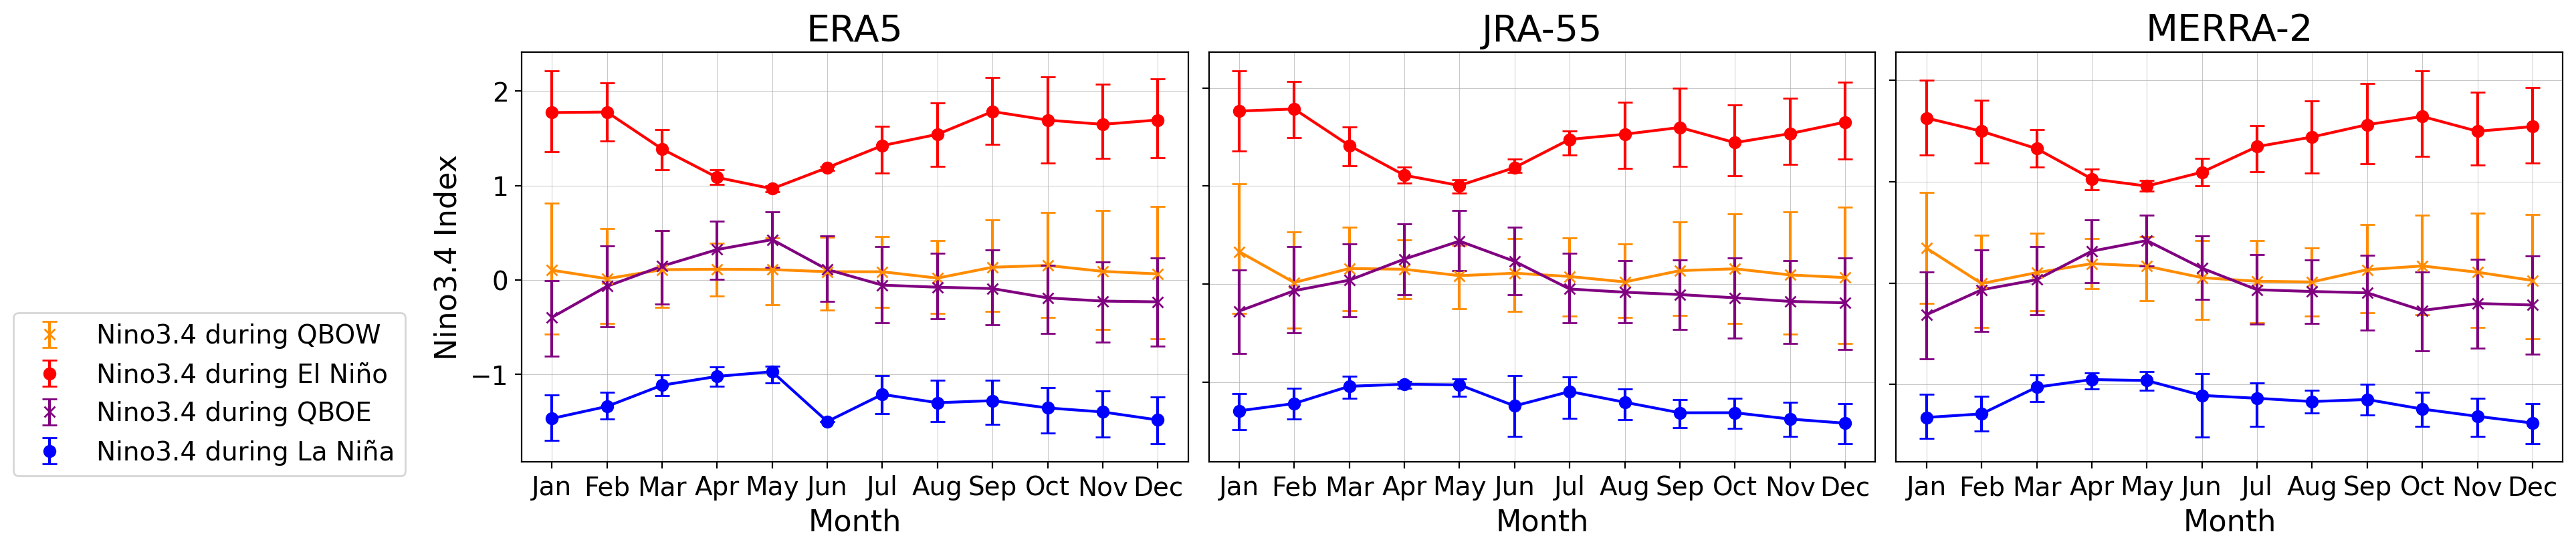

In [76]:
center_months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4),
    dpi=200,
    sharex=True,
    constrained_layout=True
)

# ERA5
plot_nino_qbo_panel(
    axes[0], center_months,
    mean_qbow_era5, err_qbow_lo_era5, err_qbow_hi_era5,
    mean_elnino_era5, err_elnino_lo_era5, err_elnino_hi_era5,
    mean_qboe_era5, err_qboe_lo_era5, err_qboe_hi_era5,
    mean_lanina_era5, err_lanina_lo_era5, err_lanina_hi_era5,
    title="ERA5"
)

# JRA-55
plot_nino_qbo_panel(
    axes[1], center_months,
    mean_qbow_jra55, err_qbow_lo_jra55, err_qbow_hi_jra55,
    mean_elnino_jra55, err_elnino_lo_jra55, err_elnino_hi_jra55,
    mean_qboe_jra55, err_qboe_lo_jra55, err_qboe_hi_jra55,
    mean_lanina_jra55, err_lanina_lo_jra55, err_lanina_hi_jra55,
    title="JRA-55"
)

# MERRA-2
plot_nino_qbo_panel(
    axes[2], center_months,
    mean_qbow_merra2, err_qbow_lo_merra2, err_qbow_hi_merra2,
    mean_elnino_merra2, err_elnino_lo_merra2, err_elnino_hi_merra2,
    mean_qboe_merra2, err_qboe_lo_merra2, err_qboe_hi_merra2,
    mean_lanina_merra2, err_lanina_lo_merra2, err_lanina_hi_merra2,
    title="MERRA-2"
)

for ax in axes:
    ax.set_ylabel("Nino3.4 Index")
    ax.label_outer()
    ax.set_xlabel("Month")
# One legend for entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(-0.2,0.1), frameon=True)

plt.suptitle("Monthly Niño3.4 During QBOE / QBOW Events", y=1.02)

plt.savefig(
    "figures/ninoindex_during_qbo_stack.pdf",
    dpi=200,
    bbox_inches="tight",
    format="pdf"
)
plt.show()


In [78]:
obs_data = {
    "ERA5": {
        "mean_qbow": mean_qbow_era5,
        "err_qbow_lo": err_qbow_lo_era5,
        "err_qbow_hi": err_qbow_hi_era5,
        "mean_qboe": mean_qboe_era5,
        "err_qboe_lo": err_qboe_lo_era5,
        "err_qboe_hi": err_qboe_hi_era5,
        "mean_elnino": mean_elnino_era5,
        "err_elnino_lo": err_elnino_lo_era5,
        "err_elnino_hi": err_elnino_hi_era5,
        "mean_lanina": mean_lanina_era5,
        "err_lanina_lo": err_lanina_lo_era5,
        "err_lanina_hi": err_lanina_hi_era5,
    },

    "JRA55": {
        "mean_qbow": mean_qbow_jra55,
        "err_qbow_lo": err_qbow_lo_jra55,
        "err_qbow_hi": err_qbow_hi_jra55,
        "mean_qboe": mean_qboe_jra55,
        "err_qboe_lo": err_qboe_lo_jra55,
        "err_qboe_hi": err_qboe_hi_jra55,
        "mean_elnino": mean_elnino_jra55,
        "err_elnino_lo": err_elnino_lo_jra55,
        "err_elnino_hi": err_elnino_hi_jra55,
        "mean_lanina": mean_lanina_jra55,
        "err_lanina_lo": err_lanina_lo_jra55,
        "err_lanina_hi": err_lanina_hi_jra55,
    },

    "MERRA2": {
        "mean_qbow": mean_qbow_merra2,
        "err_qbow_lo": err_qbow_lo_merra2,
        "err_qbow_hi": err_qbow_hi_merra2,
        "mean_qboe": mean_qboe_merra2,
        "err_qboe_lo": err_qboe_lo_merra2,
        "err_qboe_hi": err_qboe_hi_merra2,
        "mean_elnino": mean_elnino_merra2,
        "err_elnino_lo": err_elnino_lo_merra2,
        "err_elnino_hi": err_elnino_hi_merra2,
        "mean_lanina": mean_lanina_merra2,
        "err_lanina_lo": err_lanina_lo_merra2,
        "err_lanina_hi": err_lanina_hi_merra2,
    }
}

with open("obs_qbo_enso.pkl", "wb") as f:
    pickle.dump(obs_data, f)

# Seasonality 

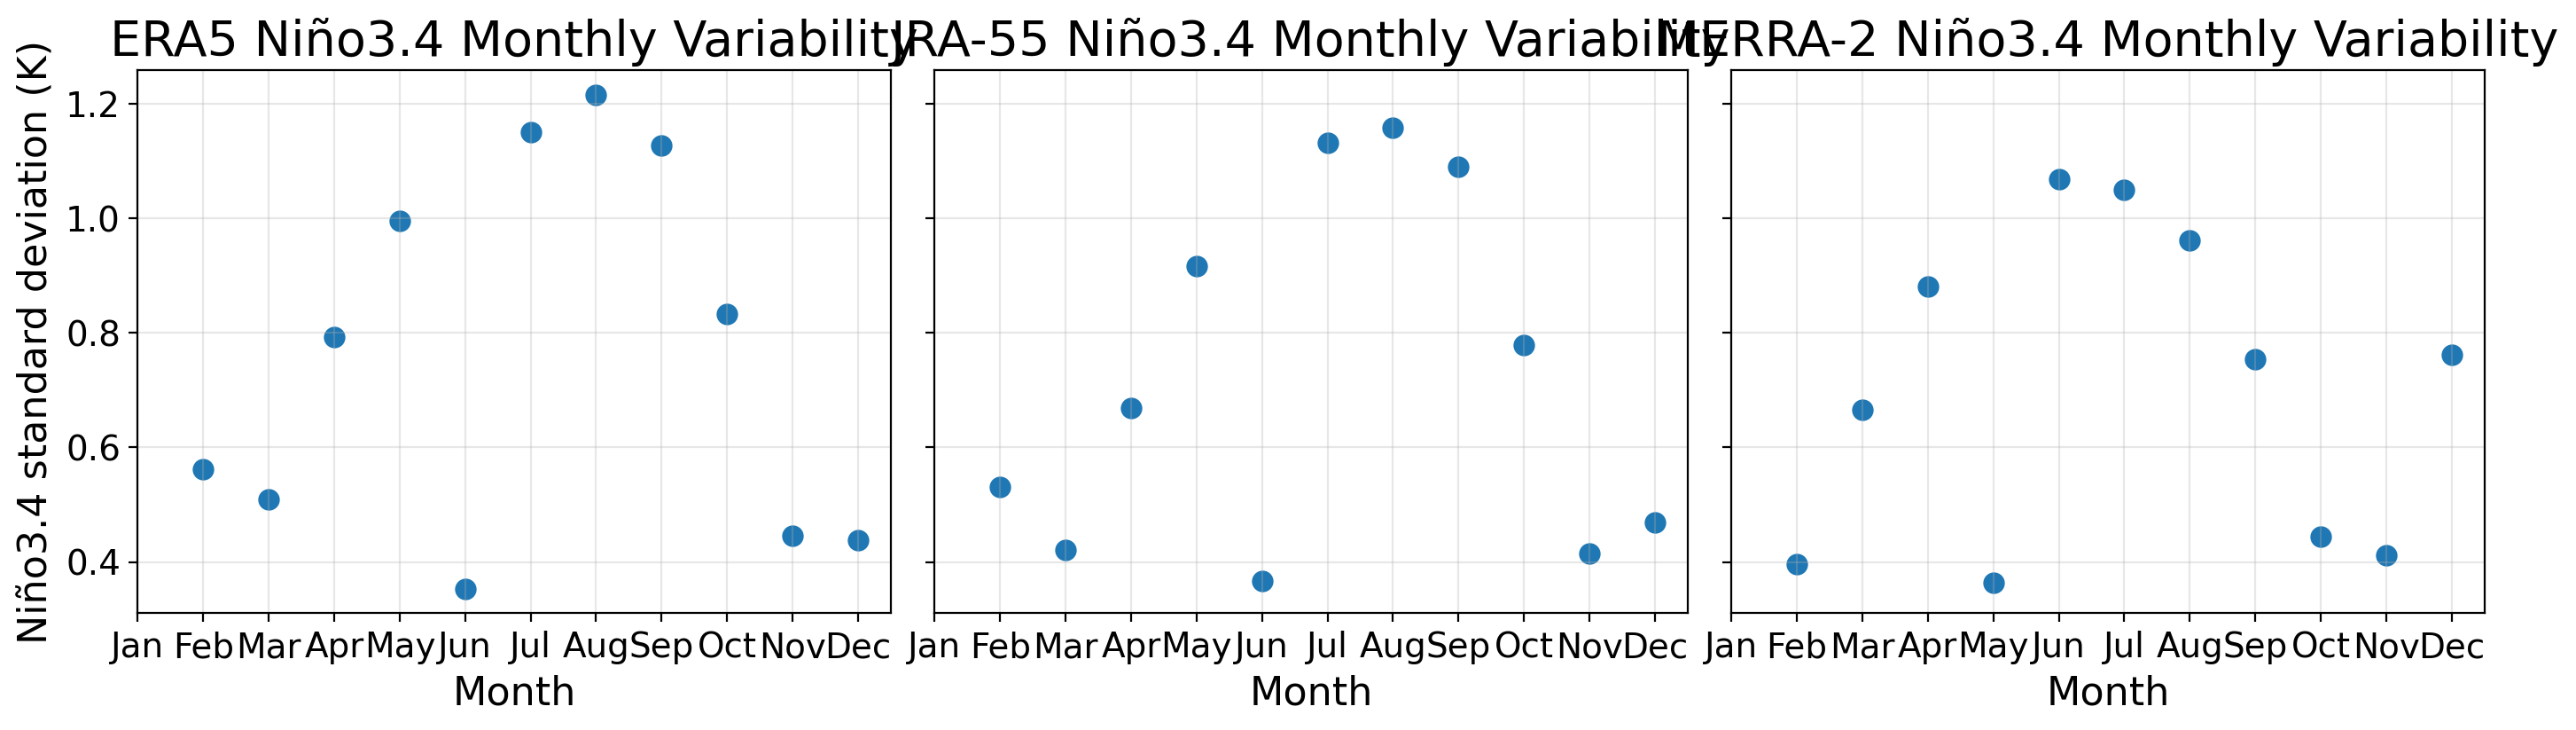

In [45]:
enso_era5 = np.asarray(nino34_obs_anom_new_reshape_era5, dtype=float)
enso_jra55 = np.asarray(nino34_obs_anom_new_reshape_jra55, dtype=float)
enso_merra2 = np.asarray(nino34_obs_anom_new_reshape_merra2, dtype=float)

# Drop trailing partial year so months line up cleanly
n_years = len(enso_era5) // 12
enso_era5 = enso_era5[: n_years * 12]
n_years = len(enso_jra55) // 12
enso_jra55 = enso_jra55[: n_years * 12]
n_years = len(enso_merra2) // 12
enso_merra2 = enso_merra2[: n_years * 12]

# Group by calendar month (0=Jan,...,11=Dec)
months_era5 = np.arange(len(enso_era5)) % 12
months_jra55 = np.arange(len(enso_jra55)) % 12
months_merra2 = np.arange(len(enso_merra2)) % 12

# Composite mean and std per month
monthly_std_era5  = np.array([enso_era5[months_era5 == m].std(ddof=1) for m in range(12)])
monthly_std_jra55  = np.array([enso_jra55[months_jra55 == m].std(ddof=1) for m in range(12)])
monthly_std_merra2  = np.array([enso_merra2[months_merra2 == m].std(ddof=1) for m in range(12)])

# 12-point scatter of monthly STD (shows seasonal growth/decay)
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

x = np.arange(1, 13)

fig, axs = plt.subplots(
    1, 3,
    figsize=(14, 4),
    dpi=200,
    sharey=True,
    constrained_layout=True
)

# ERA5
axs[0].scatter(x, monthly_std_era5, s=60)
axs[0].set_title("ERA5 Niño3.4 Monthly Variability")
axs[0].set_ylabel("Niño3.4 standard deviation (K)")

# JRA-55
axs[1].scatter(x, monthly_std_jra55, s=60)
axs[1].set_title("JRA-55 Niño3.4 Monthly Variability")

# MERRA-2
axs[2].scatter(x, monthly_std_merra2, s=60)
axs[2].set_title("MERRA-2 Niño3.4 Monthly Variability")

for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Month")
plt.savefig(
    "/glade/u/home/kkoepnick/qbo-enso/figures/nino34_monthly_std_alldata.pdf",
    dpi=200,
    bbox_inches="tight",
    format="pdf"
)
plt.show()

In [46]:
wind_test_era5 = wind_comp_test_era5.values.reshape(era5_numyrs*12)#[:40*12]
wind_test_jra55 = wind_comp_test_jra55.values.reshape(jra55_numyrs*12)
wind_test_merra2 = wind_comp_test_merra2.values.reshape(merra2_numyrs*12)

In [47]:
wind_test_era5.shape[0]/12

44.0

In [48]:
from scipy.signal import find_peaks

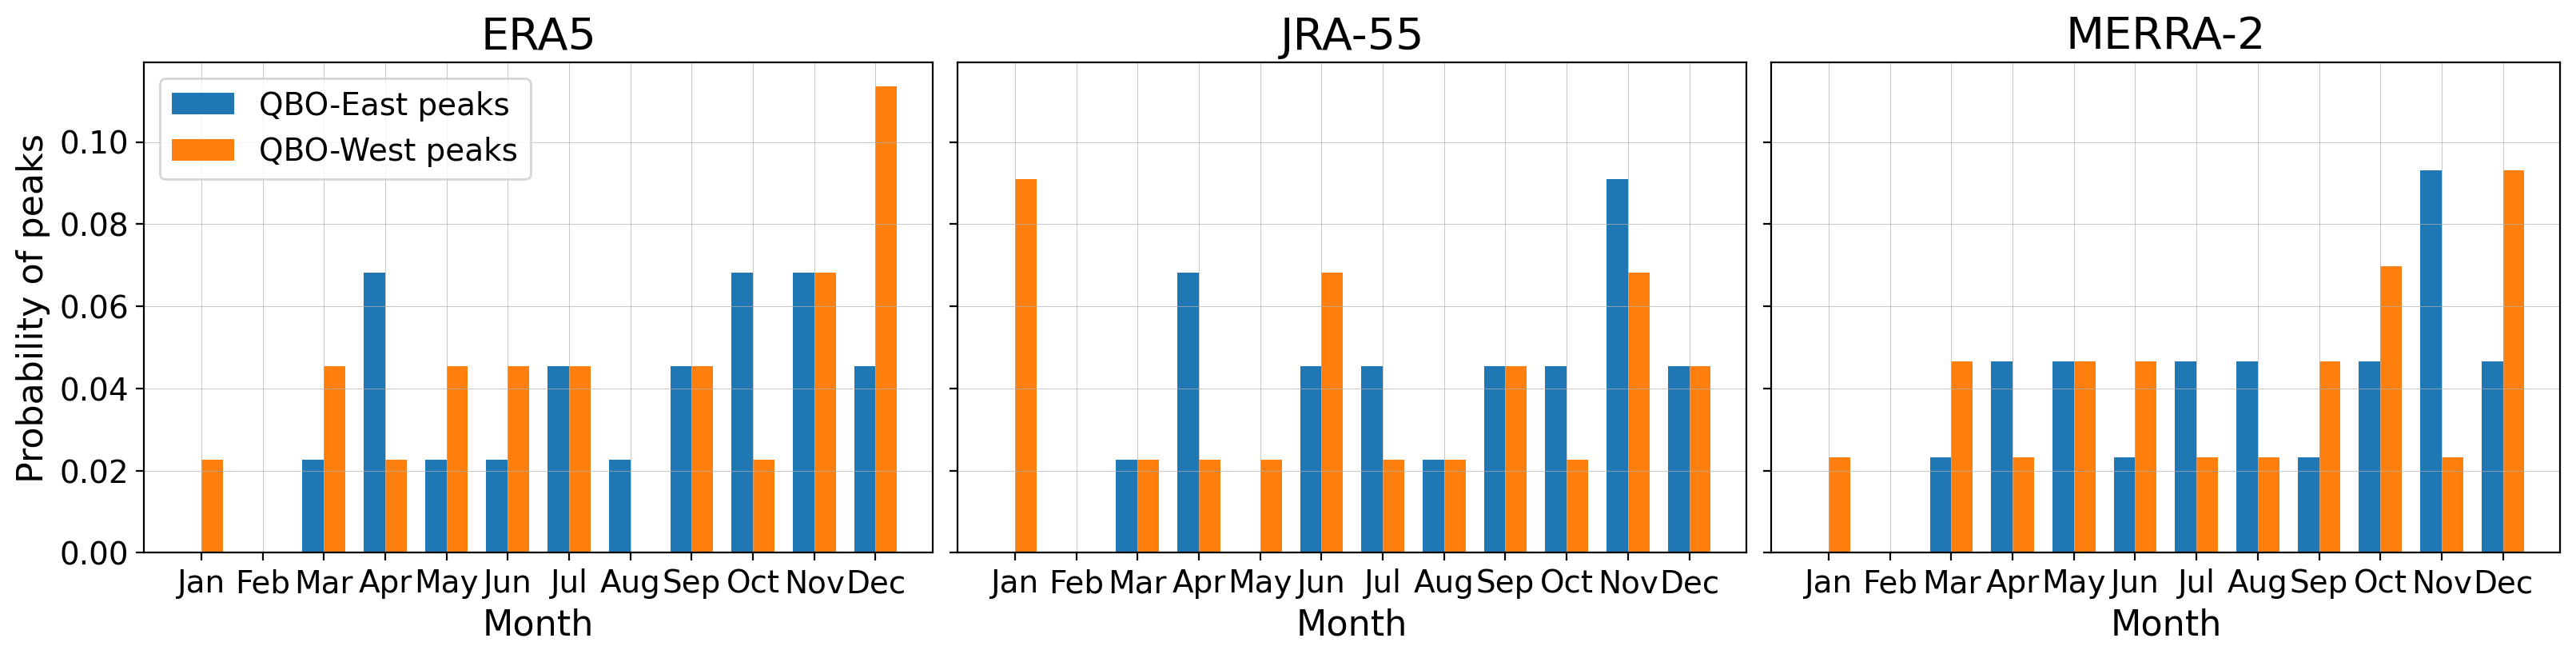

In [77]:
# QBOE peaks = local maxima of wind_comp_test
east_peaks_era5, _ = find_peaks(wind_test_era5, distance=15)
# QBOW peaks = local minima 
west_peaks_era5, _ = find_peaks(-wind_test_era5, distance=15)

east_peaks_jra55, _ = find_peaks(wind_test_jra55, distance=15)
west_peaks_jra55, _ = find_peaks(-wind_test_jra55, distance=15)

east_peaks_merra2, _ = find_peaks(wind_test_merra2, distance=15)
west_peaks_merra2, _ = find_peaks(-wind_test_merra2, distance=15)

# convert peak indices to month numbers (1–12)
east_months_era5 = (east_peaks_era5 % 12) + 1
west_months_era5 = (west_peaks_era5 % 12) + 1

east_months_jra55 = (east_peaks_jra55 % 12) + 1
west_months_jra55 = (west_peaks_jra55 % 12) + 1

east_months_merra2 = (east_peaks_merra2 % 12) + 1
west_months_merra2 = (west_peaks_merra2 % 12) + 1

# 4. Count occurrences per month
months = np.arange(1, 13)
east_counts_era5 = np.bincount(east_months_era5 - 1, minlength=12) / era5_numyrs
west_counts_era5 = np.bincount(west_months_era5 - 1, minlength=12) / era5_numyrs

east_counts_jra55 = np.bincount(east_months_jra55 - 1, minlength=12) / jra55_numyrs
west_counts_jra55 = np.bincount(west_months_jra55 - 1, minlength=12) / jra55_numyrs

east_counts_merra2 = np.bincount(east_months_merra2 - 1, minlength=12) / merra2_numyrs
west_counts_merra2 = np.bincount(west_months_merra2 - 1, minlength=12) / merra2_numyrs

# 5. Plot both distributions together
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

width = 0.35  # width of the bars

fig, axs = plt.subplots(
    1, 3,
    figsize=(16, 4),
    dpi=200,
    sharey=True,
    constrained_layout=True
)

# ---- ERA5 ----
axs[0].bar(months - width/2, east_counts_era5, width, label="QBO-East peaks")
axs[0].bar(months + width/2, west_counts_era5, width, label="QBO-West peaks")
axs[0].set_title("ERA5")
axs[0].set_ylabel("Probability of peaks")

# ---- JRA-55 ----
axs[1].bar(months - width/2, east_counts_jra55, width)
axs[1].bar(months + width/2, west_counts_jra55, width)
axs[1].set_title("JRA-55")

# ---- MERRA-2 ----
axs[2].bar(months - width/2, east_counts_merra2, width)
axs[2].bar(months + width/2, west_counts_merra2, width)
axs[2].set_title("MERRA-2")

for ax in axs.flatten():
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.grid(lw=0.25)

# One legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(frameon=True)

# plt.savefig(
#     "/glade/u/home/kkoepnick/qbo-enso/figures/seasonal_qbo_peaks_alldata.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )
plt.show()

In [19]:
winds_obs = {}

winds_obs["ERA5"] = wind_test_era5
winds_obs["MERRA2"] = wind_test_merra2
winds_obs["JRA55"] = wind_test_jra55

In [21]:
import pickle

with open("/glade/u/home/kkoepnick/qbo-enso/saved_data/winds_obs.pkl", "wb") as f:
    pickle.dump(winds_obs, f)